In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Epoch 1/15 train Loss:0.5695 Acc:0.7289
Epoch 1/15 validation Loss:0.2889 Acc:0.8643
Epoch 2/15 train Loss:0.4142 Acc:0.8007
Epoch 2/15 validation Loss:0.0880 Acc:0.9714
Epoch 3/15 train Loss:0.4473 Acc:0.8133
Epoch 3/15 validation Loss:0.0805 Acc:0.9714
Epoch 4/15 train Loss:0.5453 Acc:0.7756
Epoch 4/15 validation Loss:0.0982 Acc:0.9571
Epoch 5/15 train Loss:0.4339 Acc:0.8276
Epoch 5/15 validation Loss:0.1911 Acc:0.8857
Epoch 6/15 train Loss:0.3701 Acc:0.8492
Epoch 6/15 validation Loss:0.1162 Acc:0.9714
Epoch 7/15 train Loss:0.4564 Acc:0.8097
Epoch 7/15 validation Loss:0.1057 Acc:0.9500
Epoch 8/15 train Loss:0.4422 Acc:0.8133
Epoch 8/15 validation Loss:0.3161 Acc:0.8643
Epoch 9/15 train Loss:0.4356 Acc:0.8294
Epoch 9/15 validation Loss:0.3817 Acc:0.8643
Epoch 10/15 train Loss:0.6062 Acc:0.7774
Epoch 10/15 validation Loss:0.1199 Acc:0.9500
Epoch 11/15 train Loss:0.5083 Acc:0.8169
Epoch 11/15 validation Loss:0.0897 Acc:0.9571
Epoch 12/15 train Loss:0.6090 Acc:0.7953
Epoch 12/15 validati

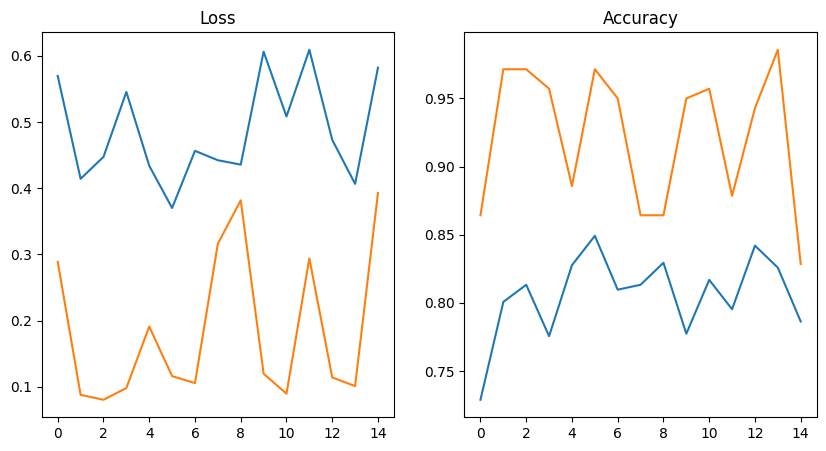

Predicted: dogs
Confidence: 0.9999924898147583


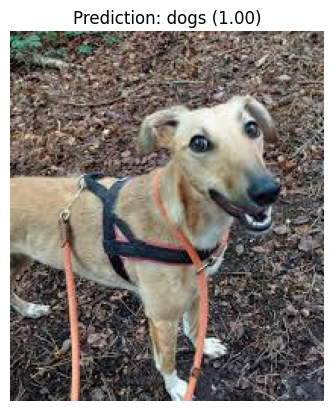

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

train_dir = "/content/drive/MyDrive/HA_EXP/train"
test_dir = "/content/drive/MyDrive/HA_EXP/test"
test_image_path = "/content/drive/MyDrive/HA_EXP/test/dogs/dog_114.jpg"

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'validation': datasets.ImageFolder(test_dir, data_transforms['validation'])
}

dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'],batch_size=4,shuffle=True,num_workers=2),
    'validation': torch.utils.data.DataLoader(image_datasets['validation'],batch_size=4,shuffle=True,num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train','validation']}
class_names = image_datasets['train'].classes

model = models.resnet18(weights="DEFAULT")
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

for name, param in model.named_parameters():
    if "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

train_loss=[]
val_loss=[]
train_acc=[]
val_acc=[]

num_epochs=15

for epoch in range(num_epochs):

    for phase in ['train','validation']:

        if phase=='train':
            model.train()
        else:
            model.eval()

        running_loss=0.0
        running_corrects=0

        for inputs,labels in dataloaders[phase]:

            inputs=inputs.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase=='train'):

                outputs=model(inputs)
                _,preds=torch.max(outputs,1)
                loss=criterion(outputs,labels)

                if phase=='train':
                    loss.backward()
                    optimizer.step()

            running_loss+=loss.item()*inputs.size(0)
            running_corrects+=torch.sum(preds==labels.data)

        epoch_loss=running_loss/dataset_sizes[phase]
        epoch_acc=running_corrects.double()/dataset_sizes[phase]

        print(f"Epoch {epoch+1}/{num_epochs} {phase} Loss:{epoch_loss:.4f} Acc:{epoch_acc:.4f}")

        if phase=='train':
            train_loss.append(epoch_loss)
            train_acc.append(epoch_acc.cpu().numpy())
        else:
            val_loss.append(epoch_loss)
            val_acc.append(epoch_acc.cpu().numpy())

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Accuracy")

plt.show()

torch.save(model.state_dict(),"/content/drive/MyDrive/HA_EXP/Save_weights.pth")

model=models.resnet18(weights=None)
model.fc=nn.Linear(model.fc.in_features,len(class_names))

model.load_state_dict(torch.load("/content/drive/MyDrive/HA_EXP/Save_weights.pth",map_location=device))

model=model.to(device)
model.eval()

transform=transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

image=Image.open(test_image_path).convert("RGB")

input_tensor=transform(image).unsqueeze(0)
input_tensor=input_tensor.to(device)

with torch.no_grad():

    output=model(input_tensor)

    probabilities=F.softmax(output,dim=1)

    predicted_class=torch.argmax(probabilities)

    confidence=probabilities[0][predicted_class].item()

predicted_class_name=class_names[predicted_class]

print("Predicted:",predicted_class_name)
print("Confidence:",confidence)

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f})")
plt.show()